# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. **What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?**
Adding a penalty to MSE discourages large model coefficients, which helps prevent overfitting. While MSE alone focuses on fitting the training data well, the penalty term forces the model to stay simple unless larger coefficients significantly improve the fit. This leads to models that generalize better to new data.
2. **How does regularization provide a way of exploring the bias-variance trade-off?** Regularization controls model complexity through the penalty parameter. A small penalty parameter results in a flexible model with low bias but high variance, while a large penalty parameter produces a simpler model with higher bias but lower variance. By tuning the penalty parameter, we can balance bias and variance to minimize overall prediction error.
3. **What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?** Ridge regression uses an L2 penalty and shrinks coefficients toward zero but does not set them exactly to zero, so all variables remain in the model. LASSO uses an L1 penalty and can shrink some coefficients exactly to zero, effectively performing variable selection. As a result, Ridge keeps all predictors, while LASSO produces a sparse model with fewer predictors.
4. **How do we typically scale variables for use in regularized regression? Why?** Variables are typically standardized to have mean 0 and variance 1 before applying regularization. This ensures that all features are on the same scale, so the penalty is applied fairly. Without scaling, variables with larger magnitudes could be penalized more heavily, distorting the model.
5. **How is the penalty $\alpha$ typically selected?** The penalty parameter is usually selected using cross-validation. Different values of $\alpha$ are tested, and the one that minimizes validation error is chosen. This helps ensure the model performs well on unseen data.
6. **When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?** No, we do not include the penalty term when computing cross-validated MSE. We only evaluate prediction error on validation data because the goal is to measure how well the model generalizes, not how well it satisfies the training constraint.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. **Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?**
The interaction term was negative = -1671212.3563918793. This means that as the age of the car increases, the effect of car mileage on the price decreases.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. **Which features are actually selected? What proportion are set equal to zero?**
The selected features were: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run^3', 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']. The proportion of coefficients set to zero is 0.1111111111111111.
7. **Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?**
When comparing the linear regression and the optimally regularized coefficients, LASSO generally shrinks all coefficients toward zero. The coefficient for Age^3 changes sign, but most coefficients have the same sign. LASSO also sets Age^2 to zero, indicating that this feature is not significant in the model. Overall, about 11% of the coefficients are set to zero, showing that LASSO performs some feature selection while keeping the most impactful terms.

In [1]:
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

Cloning into 'get_data'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 5.94 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


interaction: -1671212.3563918793


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.197e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.184e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.170e+13, tolerance: 1.316e

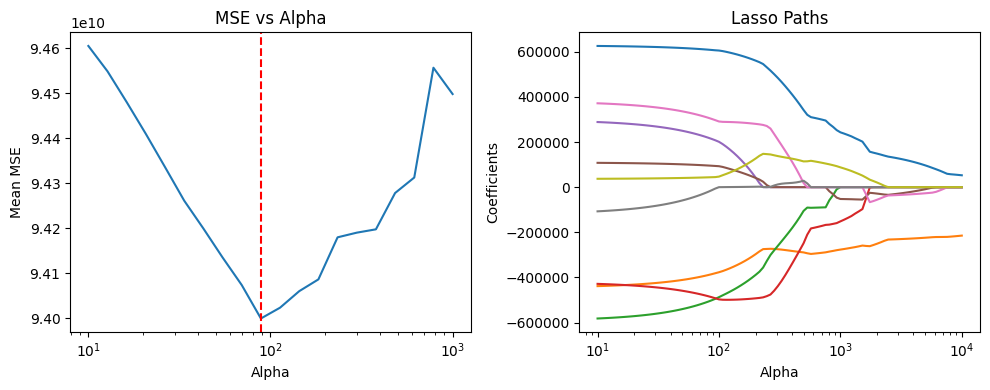

selected: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run^3'
 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
proportion zero: 0.1111111111111111

Coefficients:
             Feature        Linear         Lasso
0        Mileage_Run  9.117748e+05  7.790762e+05
1                Age -2.481722e+05 -1.339534e+05
2      Mileage_Run^2 -2.072926e+05 -2.015634e+05
3    Mileage_Run Age -1.671212e+06 -1.322419e+06
4              Age^2  3.505507e+05  0.000000e+00
5      Mileage_Run^3 -6.514490e+04 -4.240952e+04
6  Mileage_Run^2 Age  3.388195e+05  2.715062e+05
7  Mileage_Run Age^2  7.167816e+05  5.415432e+05
8              Age^3 -2.100379e+05  1.374220e+04


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.metrics import mean_squared_error

# set up
df = pd.read_csv('/content/data/cars_hw.csv')
df['Age'] = 2026 - df['Make_Year']
X = df[['Mileage_Run', 'Age']]
y = df['Price']

# 1a and 1b
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# linear regression
lr = LinearRegression().fit(X_scaled, y)

coeffs_lr = dict(zip(feature_names, lr.coef_))
print(f"interaction: {coeffs_lr.get('Mileage_Run Age')}")

# lasso
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000).fit(X_scaled, y)

# plot cv mse
mse_path = lasso_cv.mse_path_.mean(axis=1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.semilogx(lasso_cv.alphas_, mse_path)
plt.axvline(lasso_cv.alpha_, linestyle='--', color='r', label='Best Alpha')
plt.title("MSE vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean MSE")

# plot coefficient paths
n_alphas = 100
alphas_path = np.logspace(1, 4, n_alphas)
coefs = []
for a in alphas_path:
    l = Lasso(alpha=a)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

plt.subplot(1, 2, 2)
ax = plt.gca()
ax.plot(alphas_path, coefs)
ax.set_xscale('log')
plt.title("Lasso Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.tight_layout()
plt.show()

# select features
selected_features = feature_names[lasso_cv.coef_ != 0]
proportion_zero = np.sum(lasso_cv.coef_ == 0) / len(lasso_cv.coef_)
print(f"selected: {selected_features}")
print(f"proportion zero: {proportion_zero}")

# comparison
df_compare = pd.DataFrame({
    'Feature': feature_names,
    'Linear': lr.coef_,
    'Lasso': lasso_cv.coef_
})
print("\nCoefficients:")
print(df_compare)

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. **Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?**
Some of the linear regression coefficients appear counterintuitive if viewes individually. For example, age is positive, age^2 is negative, and age^3 is positive. These conflicting signs occur because the model includes higher-order polynomial terms, which means the effect of age on the outcome is nonlinear. Similarly, interaction terms like age serum_creatinine or age ejection_fraction indicate that the effect of one variable depends on another. The inclusion of higher-order and interaction terms allows the model to capture these nonlinear relationships, which is why we see those contradictions in individual coefficient signs.
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. **Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.**
The model selects ejection_fraction, serum_creatinine
age^3, ejection_fraction^3, ejection_fraction^2 serum_creatinine
serum_creatinine^3, anaemia, diabetes, high_blood_pressure, diabetes high_blood_pressure, diabetes smoking, and high_blood_pressure smoking.
The proportion set to zero is 0.5862068965517241, indicating that the model found many of the features to not contribute.
The only features that increased in magnitude from linear regression to lasso were anaemia (0.008093 -> 0.014178) and high_blood_pressure (-0.007934 -> 0.013608), and they increased very slightly.
The features that change sign are serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, serum_creatinine^3, diabetes, and high_blood_pressure.
The sign patterns for LASSO make more sense than for the linear regression model. In the linear regression, many higher-order and interaction terms have coefficients with counterintuitive signs due to overfitting and high variance. LASSO shrinks less important coefficients to zero, keeping only the most influential variables. By reducing variance at the cost of slightly increasing bias, LASSO produces coefficients with signs that align better with medical information (for example, lower ejection fraction increases risk), showing the bias-variance trade-off.

linear regression coefficients:
age                                   1.539156
ejection_fraction                    -2.192494
serum_creatinine                     -0.853588
age^2                                -3.678654
age ejection_fraction                -0.600918
age serum_creatinine                  1.841563
ejection_fraction^2                   3.430976
ejection_fraction serum_creatinine    2.673394
serum_creatinine^2                   -2.647041
age^3                                 1.993135
dtype: float64


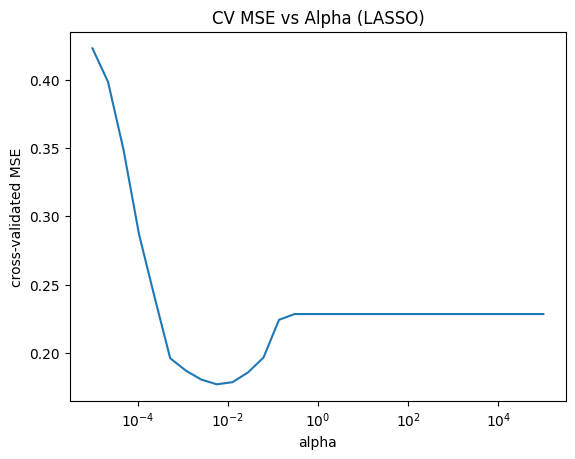

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1335358515879932, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012804029935630012, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.358315720381807, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

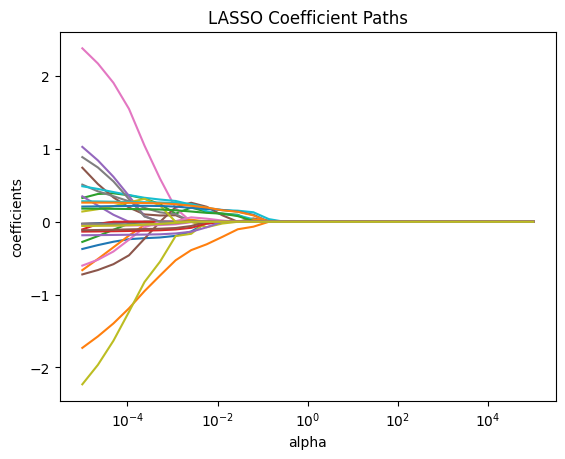


selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

proportion set to zero: 0.5862068965517241

Coefficient Comparison:
                                          Linear     LASSO  \
age                                     1.539156 -0.000000   
ejection_fraction                      -2.192494 -0.329656   
serum_creatinine                       -0.853588  0.116875   
age^2                                  -3.678654  0.000000  

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
import matplotlib.pyplot as plt


df = pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")

cont_vars = ["age", "ejection_fraction", "serum_creatinine"]
X_cont = df[cont_vars]

# polynomial degree-3 expansion
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)
feature_names_cont = poly_cont.get_feature_names_out(cont_vars)

# standardize
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

# dummy/categorical variables
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
X_cat = df[cat_vars]

# expansion of dummy/categorical variables
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_poly = poly_cat.fit_transform(X_cat)
feature_names_cat = poly_cat.get_feature_names_out(cat_vars)

# create matrix
import numpy as np
X_final = np.hstack([X_cont_scaled, X_cat_poly])
feature_names = np.concatenate([feature_names_cont, feature_names_cat])

y = df["DEATH_EVENT"] # target

# linear regression
linreg = LinearRegression()
linreg.fit(X_final, y)
coeffs_lr = pd.Series(linreg.coef_, index=feature_names)

print("linear regression coefficients:")
print(coeffs_lr.head(10))

# lasso with cv
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=500000)
lasso_cv.fit(X_final, y)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

# plot CV MSE vs alpha
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure()
plt.plot(lasso_cv.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("cross-validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")
plt.show()

# coefficient paths
alphas_lasso, coefs_lasso, _ = lasso_path(X_final, y, alphas=alphas)

plt.figure()
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=feature_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

# selected features
selected = lasso_coefs[lasso_coefs != 0]
prop_zero = np.sum(lasso_coefs == 0) / len(lasso_coefs)

print("\nselected features:")
print(selected)
print("\nproportion set to zero:", prop_zero)

# comparison
comparison = pd.DataFrame({
    "Linear": coeffs_lr,
    "LASSO": lasso_coefs
})
comparison["Increased Magnitude"] = abs(comparison["LASSO"]) > abs(comparison["Linear"])
comparison["Sign Changed"] = np.sign(comparison["LASSO"]) != np.sign(comparison["Linear"])

print("\nCoefficient Comparison:")
print(comparison)

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?